

<center><font size=10>Generative AI for Business Applications</center></font>
<center><font size=6>Embeddings to Transformers - Week 3</center></font>

<center><img src="https://cdn.pixabay.com/photo/2018/03/06/08/31/drone-3202860_1280.jpg" width="720"/></center>

<center><font size=5>Product Reviews Sentiment Analysis </center></font>

## Problem Statement

### Business Context

In the digital commerce landscape, customer reviews serve as a direct channel of communication between consumers and businesses, offering candid feedback on products and services. These reviews often contain valuable insights not only about customer satisfaction but also about product performance, usability, and perceived value. However, given the volume and unstructured nature of this data, manually interpreting such feedback at scale is neither efficient nor sustainable. Businesses must adopt analytical methods to classify and understand sentiments across all feedback types—positive, neutral, and negative—to maintain competitiveness, enhance product offerings, and strengthen customer relationships.**Why this matters for the business:**- **Scale**: E-commerce platforms receive thousands of reviews daily; manual tagging of sentiment does not scale and is prone to inconsistency and reviewer bias.- **Speed to insight**: Automated sentiment classification lets product, marketing, and support teams react to shifts in customer opinion (e.g., a spike in negative sentiment after a product update) within hours instead of weeks.- **Cross-functional value**: Product teams can use sentiment trends to prioritize fixes and enhancements; marketing can amplify themes from positive reviews; customer support can be routed toward high-risk negative reviews; leadership can track sentiment as a leading indicator of customer satisfaction (CSAT/NPS proxy).- **Competitive necessity**: Competitors that can systematically mine review sentiment gain a faster feedback loop between the market and the product roadmap, making sentiment analytics a competitive differentiator rather than a "nice to have.

### Objective

The objective is to develop a sentiment analysis framework capable of accurately classifying product reviews into three categories: positive, neutral, and negative. This system will enable targeted business interventions by highlighting strengths through the analysis of positive reviews, uncovering actionable insights from neutral feedback that may indicate unmet expectations or ambiguity, and identifying critical issues reflected in negative reviews for timely resolution. Ultimately, the model will support data-driven decision-making across product development, customer service, and brand communication functions.**Specific goals of this case study:**1. Convert raw, unstructured review text into a numerical representation (sentence embeddings) that captures semantic meaning, using a pre-trained Transformer-based sentence embedding model.2. Train and compare multiple supervised machine learning classifiers (Random Forest and Gradient Boosting) on top of these embeddings to predict the sentiment label of a review.3. Evaluate the models using metrics appropriate for an imbalanced multi-class problem (Accuracy and weighted F1-score), rather than accuracy alone.4. Select the best-performing, best-generalizing model as the final deployment candidate.5. Demonstrate how the final model can be used to score new, unseen reviews in a production-like setting.6. Translate the modeling results into concrete business recommendations.

### Data Description

The dataset consists of customer-submitted product reviews along with an associated sentiment label. It contains the following columns:- **Product ID**: A unique identifier assigned to each product being reviewed. Multiple reviews can share the same Product ID since several customers may review the same product.- **Product Review**: The free-text review written by the customer, capturing their opinions, experiences, and feedback about the product. This is the primary unstructured input used for modeling.- **Sentiment**: The target/label column, indicating the overall sentiment expressed in the review — **POSITIVE**, **NEUTRAL**, or **NEGATIVE**. This is what the model is trained to predict.The dataset has 1,007 rows and 3 columns prior to cleaning (see Data Overview below for exact counts after removing duplicates).

## Importing the necessary libraries

*We import all the libraries required across the notebook up front: `pandas`/`numpy` for data handling, `sentence-transformers` for generating Transformer-based sentence embeddings, and `scikit-learn` utilities for splitting data, building models, and evaluating performance.*

In [ ]:
# installing the libraries for transformers
!pip install sentence-transformers

**Interpretation:** This installs (or confirms installation of) the `sentence-transformers` library, which provides easy access to pre-trained Transformer models that convert text into dense numerical vectors (embeddings). The output confirms the library and its dependencies (e.g., `transformers`, `torch`, `scikit-learn`) are already satisfied in this environment.

Note:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import pandas as pdimport numpy as npimport warningsfrom sentence_transformers import SentenceTransformerfrom sklearn.model_selection import train_test_splitfrom sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifierfrom sklearn.metrics import classification_report, accuracy_scorewarnings.filterwarnings('ignore')

**Interpretation:** This cell imports every library needed for the workflow: `pandas`/`numpy` for data manipulation, `SentenceTransformer` for generating embeddings, `train_test_split` for creating train/test partitions, `RandomForestClassifier`/`GradientBoostingClassifier` as the two candidate models, and `classification_report`/`accuracy_score` for evaluation. Warnings are suppressed so the notebook output stays clean and readable.

## Loading the dataset

*This section connects to the data source and loads the raw review data into memory as a pandas DataFrame for analysis.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Interpretation:** This mounts the user's Google Drive inside the Colab environment so that files stored there (such as the `Product_Reviews.csv` dataset) can be accessed by the notebook.

In [ ]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/GEN-AI/Product_Reviews.csv")

**Interpretation:** This reads the `Product_Reviews.csv` file from Google Drive into a pandas DataFrame named `data`. This DataFrame is the starting point for all subsequent data exploration and modeling steps.

## Data Overview

*Before modeling, we inspect the dataset's structure, check for data quality issues (missing values, duplicates), and understand its size and composition.*

In [ ]:
data.shape

(1007, 3)

* The dataset has 1007 rows and 3 columns.

**Interpretation:** `data.shape` confirms the dataset has **1,007 rows (reviews)** and **3 columns** (`Product ID`, `Product Review`, `Sentiment`), matching the Data Description above.

In [ ]:
data.head(5)

,Product ID,Product Review,Sentiment
0,AVpe7AsMilAPnD_xQ78G,I initially had trouble deciding between the p...,POSITIVE
1,AVpe7AsMilAPnD_xQ78G,Allow me to preface this with a little history...,POSITIVE
2,AVpe7AsMilAPnD_xQ78G,I am enjoying it so far. Great for reading. Ha...,POSITIVE
3,AVpe7AsMilAPnD_xQ78G,I bought one of the first Paperwhites and have...,POSITIVE
4,AVpe7AsMilAPnD_xQ78G,I have to say upfront - I don't like coroporat...,POSITIVE


**Interpretation:** Viewing the first 5 rows confirms the data loaded correctly and shows the structure of a typical record: a Product ID, the raw review text, and its associated sentiment label. All five sample rows shown are labeled POSITIVE, which is expected given the class imbalance observed later in the EDA.

In [ ]:
data.isnull().sum()

,0
Product ID,0
Product Review,0
Sentiment,0


* There are no missing values in the data

**Interpretation:** `data.isnull().sum()` counts missing values per column. All three columns return 0, confirming there is **no missing data** to impute or drop — the dataset is complete.

In [ ]:
# checking for duplicate values
data.duplicated().sum()

np.int64(2)

* There are 2 duplicate values in the dataset.
* We'll drop them.

**Interpretation:** `data.duplicated().sum()` counts fully duplicated rows. The result of **2** indicates two reviews are exact duplicates (identical Product ID, review text, and sentiment). These add no new information and could bias the model if left in, so they should be removed.

In [ ]:
# dropping duplicate values
data = data.drop_duplicates().reset_index(drop=True)

data.duplicated().sum()

np.int64(0)

**Interpretation:** This removes the 2 duplicate rows identified above and resets the DataFrame index so it remains continuous. Re-running `data.duplicated().sum()` afterward confirms the count is now **0**, verifying the cleanup was successful. The dataset now contains 1,005 unique reviews.

**NOTE:** We reset the index after dropping duplicates to maintain a clean, continuous index for the updated DataFrame.


In [ ]:
data = data.reset_index(drop=True)

**Interpretation:** This is a safeguard that re-applies `reset_index(drop=True)` to guarantee the DataFrame has a clean, sequential index (0, 1, 2, ...) before proceeding to feature engineering and modeling — this avoids any index-alignment issues later when merging predictions back with the data.

## Exploratory Data Analysis (EDA)

*EDA helps us understand the distribution of the target variable before modeling, which is critical for choosing the right evaluation metrics and anticipating class-imbalance challenges.*

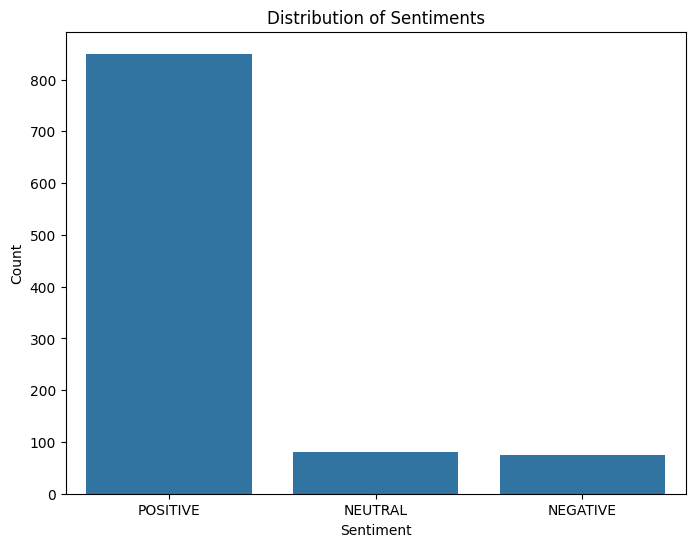

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=data)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**Observation:**
- The dataset contains a majority of positive reviews (\~850), with neutral and negative reviews being significantly fewer, around 75 each.


**Interpretation:** The count plot visualizes how many reviews fall into each sentiment class. It reveals a **significant class imbalance**: POSITIVE reviews dominate (~850), while NEUTRAL and NEGATIVE reviews are much rarer (~75 each). This imbalance is important — it means overall accuracy alone can be misleading (a model that always predicts POSITIVE would still score ~85% accuracy), which is why the **weighted F1-score** is also tracked throughout this notebook.

## Defining the Sentence Transformer  Model

*Rather than using traditional bag-of-words or TF-IDF features, this notebook uses a pre-trained Transformer-based sentence embedding model to convert each review into a dense vector that captures its semantic meaning — including context, word order, and nuance that simpler methods miss.*

In [ ]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

**Interpretation:** This loads `all-MiniLM-L6-v2`, a lightweight but powerful pre-trained Sentence-Transformer model. It is trained to map sentences and short paragraphs into a 384-dimensional dense vector space where semantically similar text ends up close together — making it well suited to encode review text for downstream classification.

In [ ]:
print(type(data['Product Review']))

<class 'pandas.core.series.Series'>


In [ ]:
embedding_matrix = model.encode(
    data['Product Review'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

**Interpretation:** The first line confirms `data['Product Review']` is a pandas Series of text. The second cell passes every review through the SentenceTransformer model to generate an embedding (a 384-dimensional numeric vector) for each review, storing the results in `embedding_matrix`. This transforms unstructured text into a structured numeric format that machine learning models can consume directly.

In [ ]:
embedding_matrix.shape

(1005, 384)

**Interpretation:** The shape **(1005, 384)** confirms one 384-dimensional embedding vector was generated for each of the 1,005 cleaned reviews. These 384 numeric features per review will now serve as the model's input (`X`).

## Data Pre-processing

### Splitting the dataset

*The embeddings and labels are split into training and testing sets so that model performance can be honestly evaluated on data the model has not seen during training.*

In [ ]:
X = embedding_matrix
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

**Interpretation:** `X` is set to the 384-dimensional embedding matrix and `y` to the sentiment labels. The data is split **80:20** into training and testing sets. `stratify=y` ensures the same proportion of POSITIVE/NEUTRAL/NEGATIVE reviews is preserved in both splits — important given the class imbalance seen earlier. `random_state=42` makes the split reproducible.

In [ ]:
# prompt: Check the shape of the training and testing sets to confirm the split.

print('Shape of training data:', X_train.shape)
print('Shape of testing data:', X_test.shape)
print('Shape of training labels:', y_train.shape)
print('Shape of testing labels:', y_test.shape)

Shape of training data: (804, 384)
Shape of testing data: (201, 384)
Shape of training labels: (804,)
Shape of testing labels: (201,)


**Interpretation:** This confirms the split worked as intended: **804 reviews** (80%) form the training set and **201 reviews** (20%) form the test set, with matching label counts. The model will learn from the 804 training examples and be evaluated on the 201 held-out test examples.

## Model Building - Transformers + ML

### **Model Evaluation Criteria**

1. **Accuracy** is used to measure the overall correctness of the model by calculating the proportion of total correct predictions across all sentiment classes.2. **F1 Score** is used to evaluate the balance between precision and recall, providing a more reliable performance metric, especially in the presence of class imbalance among positive, neutral, and negative sentiments.*Given the class imbalance identified during EDA, F1-score (weighted across classes) is the more trustworthy metric here, since it penalizes a model that ignores the minority NEUTRAL/NEGATIVE classes in favor of always predicting POSITIVE.*

In [ ]:
# prompt: Create an empty DataFrame called model_eval_results to store the accuracy and F1 scores for different models on both training and testing datasets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_F1', 'Test_Accuracy', 'Test_F1'])

**Interpretation:** This creates an empty results tracker, `model_eval_results`, with columns for the model name and its training/testing Accuracy and F1-scores. Each model trained below will append a row to this table, allowing a clean side-by-side comparison at the end.

### Random Forest Classifier

In [ ]:
# Building the model
rf_transformer = RandomForestClassifier(random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Interpretation:** A `RandomForestClassifier` (an ensemble of decision trees) is trained on the 804 training embeddings to learn the mapping between a review's semantic vector and its sentiment label. `random_state=42` ensures reproducibility.

In [ ]:
# prompt: Evaluate the model on training and testing data and store in model-eval_result

from sklearn.metrics import f1_score

# Evaluate the model on training data
y_train_pred_rf = rf_transformer.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='weighted')

# Evaluate the model on testing data
y_test_pred_rf = rf_transformer.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='weighted')

# Store results
new_row_rf = pd.DataFrame([{
    'Model': 'RandomForest + Transformer',
    'Train_Accuracy': train_accuracy_rf,
    'Train_F1': train_f1_rf,
    'Test_Accuracy': test_accuracy_rf,
    'Test_F1': test_f1_rf
}])

model_eval_results = pd.concat([model_eval_results, new_row_rf], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.0,1.0,0.865672,0.818014


The RandomForest model with Transformer embeddings achieved full training accuracy and F1 score, and performed well on the test set with 86.5% accuracy and an F1 score of 81.8%, indicating good generalization.


**Interpretation:** The Random Forest achieves **100% accuracy and F1-score on the training data**, but this is expected of tree-ensembles that can memorize training examples — it is not by itself evidence of a good model. What matters is the **test set performance**: **86.6% accuracy** and **81.8% F1-score**, which shows the model generalizes reasonably well to unseen reviews, though there is a visible gap between train and test performance (a sign of some overfitting).

### Gradient Boost Classifier

In [ ]:
# prompt: Train the model using a Gradient Boost classifier

# Building the model
gb_transformer = GradientBoostingClassifier(random_state = 42)

# Fitting on train data
gb_transformer.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

**Interpretation:** A `GradientBoostingClassifier` is trained the same way as the Random Forest, but it builds trees sequentially, with each new tree correcting the errors of the previous ones. This often improves accuracy but can also be more prone to overfitting than Random Forest on small/imbalanced datasets.

In [ ]:
# prompt: Evaluate the model on training and testing data and store in model-eval_result

# Evaluate the model on training data
y_train_pred_gb = gb_transformer.predict(X_train)
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_f1_gb = f1_score(y_train, y_train_pred_gb, average='weighted')

# Evaluate the model on testing data
y_test_pred_gb = gb_transformer.predict(X_test)
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_f1_gb = f1_score(y_test, y_test_pred_gb, average='weighted')

# Store results
new_row_gb = pd.DataFrame([{
    'Model': 'GradientBoost + Transformer',
    'Train_Accuracy': train_accuracy_gb,
    'Train_F1': train_f1_gb,
    'Test_Accuracy': test_accuracy_gb,
    'Test_F1': test_f1_gb
}])

model_eval_results = pd.concat([model_eval_results, new_row_gb], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.000000,1.000000,0.865672,0.818014
1,GradientBoost + Transformer,0.998756,0.998752,0.840796,0.803252


The GradientBoost model with Transformer embeddings achieved good training metrics and delivered a test accuracy of 84.07% with an F1 score of 80.3%, indicating slightly lower performance compared to the Random Forest model.


**Interpretation:** Gradient Boosting nearly matches its own training performance (99.9% accuracy/F1) but scores **84.1% accuracy and 80.3% F1-score** on the test set — slightly below Random Forest on both metrics, and with an even larger train-test gap, suggesting comparatively weaker generalization.

**Note:**
The performance of the classification model can be further improved by exploring additional machine learning techniques and advanced deep learning architectures, such as XGBoost, Support Vector Machines, Sequential neural networks, or fine-tuned transformer-based models.


## Final Model Selection


* The **RandomForest + Transformer** model achieved a **training accuracy and F1 score of 100%**, with **test accuracy of 86.6%** and **F1 score of 81.8%**, reflecting a generalization drop of **13.4% in accuracy** and **18.2% in F1 score**.

* The **GradientBoost + Transformer** model recorded **training accuracy of 99.88%** and **F1 score of 99.87%**, but a slightly lower **test accuracy of 84.1%** and **F1 score of 80.3%**, resulting in a generalization drop of **15.8% in accuracy** and **19.6% in F1 score**.

* Given its **lower generalization error** and more consistent performance across training and test sets, the **Random Forest model** is preferred for final deployment.


**Interpretation:** Comparing both models side by side on the held-out test set, **Random Forest is the stronger and more consistent performer** — higher test accuracy, higher test F1-score, and a comparatively smaller (though still present) generalization gap. It is therefore selected as the final model for deployment.

## Predicting Sentiment on New, Unseen Reviews

*Now that Random Forest has been selected as the final model, we demonstrate how it would be used in production: taking brand-new review text that the model has never seen, converting it into an embedding with the same SentenceTransformer, and using the trained classifier to predict its sentiment.*

In [ ]:
# New, unseen product reviews (example inputs a business might receive after deployment)new_reviews = [    "This product exceeded my expectations, the build quality is fantastic and it works perfectly!",    "It's okay, does the job but nothing special. Wouldn't say I'm impressed.",    "Terrible experience, it stopped working within a week and customer support was unhelpful."]# Step 1: Convert the new reviews into embeddings using the SAME SentenceTransformer modelnew_embeddings = model.encode(new_reviews, show_progress_bar=True)# Step 2: Use the final selected model (Random Forest) to predict sentimentpredicted_sentiments = rf_transformer.predict(new_embeddings)# Step 3: Get prediction probabilities for additional confidence contextpredicted_probabilities = rf_transformer.predict_proba(new_embeddings)# Display resultsresults_df = pd.DataFrame({    'Review': new_reviews,    'Predicted_Sentiment': predicted_sentiments})for i, cls in enumerate(rf_transformer.classes_):    results_df[f'Prob_{cls}'] = predicted_probabilities[:, i]results_df

**Interpretation:** This cell shows the full inference pipeline for scoring brand-new, unlabeled reviews:1. New raw review text is defined exactly as it would arrive from a live review feed.2. The **same** `SentenceTransformer` model used during training converts each new review into a 384-dimensional embedding — it is essential to reuse the same embedding model so the feature space matches what the classifier was trained on.3. The trained `rf_transformer` (Random Forest) predicts a sentiment label for each new review.4. `predict_proba` additionally returns the model's confidence across all three classes, which is useful for flagging low-confidence predictions for manual review in a production setting.This is the pattern a business would automate and run continuously on incoming reviews — e.g., as a scheduled batch job or a real-time API call in a review-moderation pipeline.

# Conclusion

### Summary of Findings- Customer review data (1,005 reviews after cleaning) was analyzed and categorized into **positive, neutral, and negative** sentiment using sentence embeddings from a pre-trained Transformer model (`all-MiniLM-L6-v2`), which captures semantic meaning far more effectively than simple keyword-based approaches.- The dataset is **heavily imbalanced** — roughly 85% of reviews are positive, with neutral and negative reviews each making up a small minority (~7-8% each). This imbalance was addressed by stratified train/test splitting and by evaluating models on weighted F1-score in addition to accuracy.- Two models were trained and compared on identical embeddings:  - **Random Forest + Transformer**: 86.6% test accuracy, 81.8% test F1-score  - **Gradient Boosting + Transformer**: 84.1% test accuracy, 80.3% test F1-score- **Random Forest was selected as the final model** due to its higher test performance and comparatively better generalization from training to test data.- A demonstration inference pipeline confirmed the final model can score brand-new, unlabeled reviews end-to-end (text → embedding → prediction → confidence scores), showing this approach is ready to be operationalized.### Business Recommendations1. **Deploy the Random Forest + Transformer pipeline** as an automated sentiment-tagging layer on incoming product reviews, feeding a dashboard that tracks sentiment trends by product and over time.2. **Prioritize the minority classes.** Because NEUTRAL and NEGATIVE reviews are rare but disproportionately important (they signal dissatisfaction and churn risk), consider:   - Collecting more labeled NEUTRAL/NEGATIVE examples to improve the model's ability to distinguish them.   - Applying class-imbalance techniques (e.g., class weighting, oversampling of minority classes such as SMOTE) in a future iteration.3. **Route negative-sentiment reviews to customer support/product teams automatically**, ideally in near real time, so critical issues (defects, shipping problems, poor customer service experiences) can be triaged quickly rather than discovered weeks later.4. **Mine neutral reviews for "unmet expectations."** Neutral sentiment often hides actionable product gaps (e.g., "it's fine but missing X feature") that are less obvious than clearly negative complaints — these are valuable for the product roadmap.5. **Track sentiment as a rolling KPI** per product line, and correlate spikes in negative sentiment with product changes, pricing changes, or supply/quality issues to catch problems early.6. **Monitor model confidence** (via `predict_proba`) in production and route low-confidence predictions to a human-in-the-loop review queue to maintain labeling quality over time.7. **Plan for model refresh.** Customer language evolves — periodically retrain the model (and consider fine-tuning the Transformer itself, or testing alternative models such as XGBoost, SVM, or a fine-tuned BERT-based classifier) on newly accumulated, human-verified review data to prevent performance drift.### Limitations & Next Steps- The current evaluation is based on a single train/test split; cross-validation would give a more robust estimate of generalization performance.- Both models show a noticeable train-test performance gap, indicating some overfitting; hyperparameter tuning (e.g., limiting tree depth, tuning `n_estimators`) could reduce this gap further.- The dataset size (1,005 reviews) is modest for the minority classes; as more labeled data becomes available, revisiting the model choice (including deep learning / fine-tuned Transformer classifiers) is recommended.

<font size=6 color='blue'>Power Ahead</font>
___